# E5: perturbed SST response

Compute the time-mean response (perturbed minus unperturbed) of +2 and +4 K SST perturbation simulations

In [1]:
import xarray as xr
import numpy as np
import os
from dask import config as dask_config
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt
import textwrap
import re
import matplotlib.ticker as mticker

from aimip_data_utils import (
    write_cache,
    read_cache,
    AIMIP_EXPERIMENT_SUBMISSIONS,
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EvaluationVariable,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_time_mean,
    load_gfdl_am4_from_cmip6_gcs,
    GFDL_CM4_AMIP_ZARR_TEMPLATE,
)

In [2]:
EVALUATION_DATES = ('1978-10-01', '2024-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
RESET_CACHE = False
RESTORE_CACHE = True

# Submission versions behind this notebook's caches. write_cache stamps them into
# each file and read_cache refuses a cache built from different ones.
CACHE_SUBMISSIONS = (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
)

EVALUATION_PRESSURE_LEVELS = [
    85000.,
    50000.,
]

EVALUATION_VARIABLES = [
    EvaluationVariable(
        standard_name='surface_specific_humidity',
        long_name='specific humidity at 2 meters',
        short_name='huss',
        units='-'
    ),
    EvaluationVariable(
        standard_name='dew_point_temperature',
        long_name='dew point temperature at 2 meters',
        short_name='tdas',
        units='K'
    ),
    EvaluationVariable(
        standard_name='surface_air_pressure',
        long_name='air pressure at the surface',
        short_name='ps',
        units='Pa'
    ),
    EvaluationVariable(
        standard_name='precipitation_flux',
        long_name='precipitation_flux at the surface',
        short_name='pr',
        units='kg / s / m **2'
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature',
        short_name='ta',
        units='K',
        standard_pressure_level_indexer={'plev': EVALUATION_PRESSURE_LEVELS},
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature at 2 meters',
        short_name='tas',
        units='K',
    ),
    EvaluationVariable(
        standard_name='surface_temperature',
        long_name='surface temperature',
        short_name='ts',
        units='K',
    ),
    EvaluationVariable(
        standard_name='geopotential_height',
        long_name='geopotential height',
        short_name='zg',
        units='m',
        standard_pressure_level_indexer={'plev': [5e4]}, # 500 hPa height only
        drop_singleton_pressure_coord=True,
    ),
]

EVALUATION_VARIABLE_SUBSET = [eval_var for eval_var in EVALUATION_VARIABLES if eval_var.short_name not in ['tdas', 'ps']]
EVALUATION_VARIABLE_SUBSET_NAMES = [eval_var.short_name for eval_var in EVALUATION_VARIABLE_SUBSET]
GFDL_AM4_AMIP_P4K_ZARR_TEMPLATE = 'gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/{varname}/gr1/v20180701'

## How to run this notebook

This notebook runs in one of two modes, set by `RESET_CACHE` / `RESTORE_CACHE` in the cell above.

**Reproduce the manuscript figures from the bundled cache** — the default (`RESTORE_CACHE = True`, `RESET_CACHE = False`). No raw data is needed: run the setup cells above, then the **Restore minimal cache** cell, then the cells in the **Manuscript figures** section. You can skip the **Data loading & processing** section and the intermediate diagnostic cells — they read the full (~1.8 TB) raw dataset.

**Regenerate the cache from the raw dataset** (`RESET_CACHE = True`, `RESTORE_CACHE = False`). Download the full submissions (see the repo `README.md` → Data) and run every cell top to bottom; the minimal cache is rewritten from scratch.

## Data loading & processing

*Skip this section when using the bundled cache.* These cells read the full raw dataset and are only needed to regenerate the cache (`RESET_CACHE = True`).

In [3]:
monthly_data, missing_files = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2

precipitation_flux
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810

../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tas/gn/v20251130/tas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tas/gn/v20251130/tas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tas/gn/v20251130/tas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tas/gn/v20251130/tas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tas/gn/v20251130/tas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/ts/gn/v20251130/ts_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-2024

../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/zg/gr/v20251130/zg_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/zg/gr/v20251130/zg_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc


ACE2.2-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-2-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20260908/huss_Amon_ACE2-2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-2-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20260908/huss_Amon_ACE2-2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-2-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20260908/huss_Amon_ACE2-2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-2-ERA5/aimip/r4i1p1f1/Amon/huss/gn/v20260908/huss_Amon_ACE2-2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-2-ERA5/aimip/r5i1p1f1/Amon/huss/gn/v20260908/huss_Amon_ACE2-2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-2-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-2-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
Not found: ../../local

...

NeuralGCM-HRD
surface_specific_humidity
Not found: ../../local_data/Google/NeuralGCM-HRD/aimip/r1i1p1f1/Amon/huss/gn/v20260304/huss_Amon_NeuralGCM-HRD_aimip_r1i1p1f1_gn_197810-202412.nc
Not found: ../../local_data/Google/NeuralGCM-HRD/aimip/r2i1p1f1/Amon/huss/gn/v20260304/huss_Amon_NeuralGCM-HRD_aimip_r2i1p1f1_gn_197810-202412.nc
Not found: ../../local_data/Google/NeuralGCM-HRD/aimip/r3i1p1f1/Amon/huss/gn/v20260304/huss_Amon_NeuralGCM-HRD_aimip_r3i1p1f1_gn_197810-202412.nc
Not found: ../../local_data/Google/NeuralGCM-HRD/aimip/r4i1p1f1/Amon/huss/gn/v20260304/huss_Amon_NeuralGCM-HRD_aimip_r4i1p1f1_gn_197810-202412.nc
Not found: ../../local_data/Google/NeuralGCM-HRD/aimip/r5i1p1f1/Amon/huss/gn/v20260304/huss_Amon_NeuralGCM-HRD_aimip_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
../../local_data/Google/NeuralGCM-HRD/aimip/r1i1p1f1/Amon/tdas/gn/v20260304/tdas_Amon_NeuralGCM-HRD_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r2i1p1f1/Amon/tdas/gn/v202603

air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip/r1i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r2i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r3i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r4i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r5i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip_r5i1p1f1_gn_197810-202412.nc


air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip/r1i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r2i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r3i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r4i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r5i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../../local_data/Google/NeuralGCM-HRD/aimip/r1i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip/r2i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD

../../local_data/Google/NeuralGCM-HRD/aimip/r5i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip_r5i1p1f1_gn_197810-202412.nc


{'ACE2.1-ERA5': ['../../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc'], 'ACE2.2-ERA5': ['../../local_data/Ai2/ACE2-2-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-2-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-2-ERA5/aimip/r3i1p1f1/Amon/tdas/

In [4]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ACE2.2-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [5]:
monthly_data_p2k, missing_files_p2k = open_aimip_data(
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p2k)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gn_197810-202412.nc


../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gr_197810-202412.nc
surface_air_pressure


../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
precipitation_flux
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gn_197810-202412.nc


../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gn_197810-202412.nc


../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gr_197810-202412.nc


...

../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r3i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r4i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r5i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r1i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r2i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p2k_r2i1p1f1_gn_197810-202412.nc


../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r3i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r4i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r5i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r1i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p2k_r1i1p1f1_gn_197810-202412.nc


../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r2i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r3i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r4i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r5i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r1i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r2i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r3i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p2k_r3i1p1f1_gn_197810-202412.nc

../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r5i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
geopotential_height
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r1i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r2i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r3i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r4i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p2k/r5i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p2k_r5i1p1f1_gn_197810-202412.nc


{'ACE2.1-ERA5': ['../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gr_197810-202412.nc'], 'ACE2.2-ERA5': ['../../local_data/Ai2/ACE2-2-ERA5/aimip-p2k/r1i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-2-ERA5/aimip-p2k/r2i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip-p2k_r2i1p1f1_gr_197810-202412.nc', '..

In [6]:
for experiment_submission_name, dataset in monthly_data_p2k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p2k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ACE2.2-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [7]:
monthly_data_p4k, missing_files_p4k = open_aimip_data(
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p4k)

ACE2.1-ERA5
surface_specific_humidity
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature


Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gr_197810-202412.nc
Not found: ../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gr_197810-202412.nc
surface_air_pressure


../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/ps/gn/v20251130/ps_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
precipitation_flux


../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gn_197810-202412.nc


../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/pr/gn/v20251130/pr_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc
../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/ta/gr/v20251130/ta_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gr_197810-202412.nc


...

../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r3i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r4i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r5i1p1f1/Amon/pr/gn/v20260304/pr_Amon_NeuralGCM-HRD_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r1i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r2i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p4k_r2i1p1f1_gn_197810-202412.nc


../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r3i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r4i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r5i1p1f1/Amon/ta/gn/v20260304/ta_Amon_NeuralGCM-HRD_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
air_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r1i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p4k_r1i1p1f1_gn_197810-202412.nc


../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r2i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r3i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r4i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r5i1p1f1/Amon/tas/gn/v20260304/tas_Amon_NeuralGCM-HRD_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
surface_temperature
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r1i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r2i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r3i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p4k_r3i1p1f1_gn_197810-202412.nc

../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r5i1p1f1/Amon/ts/gn/v20260304/ts_Amon_NeuralGCM-HRD_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
geopotential_height
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r1i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r2i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r3i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r4i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../../local_data/Google/NeuralGCM-HRD/aimip-p4k/r5i1p1f1/Amon/zg/gn/v20260304/zg_Amon_NeuralGCM-HRD_aimip-p4k_r5i1p1f1_gn_197810-202412.nc


{'ACE2.1-ERA5': ['../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gr_197810-202412.nc'], 'ACE2.2-ERA5': ['../../local_data/Ai2/ACE2-2-ERA5/aimip-p4k/r1i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc', '../../local_data/Ai2/ACE2-2-ERA5/aimip-p4k/r2i1p1f1/Amon/tdas/gr/v20260908/tdas_Amon_ACE2-2-ERA5_aimip-p4k_r2i1p1f1_gr_197810-202412.nc', '..

In [8]:
for experiment_submission_name, dataset in monthly_data_p4k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p4k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ACE2.2-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD-1.5 v0.9 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [9]:
perturbation_submissions = sorted(list(
    set(monthly_data.keys()) & set(monthly_data_p2k.keys()) & set(monthly_data_p4k.keys())
), key=lambda x: x.lower())
perturbed_sst_response = {}
for k in perturbation_submissions:
    print(k)
    dataset_eval_vars = [var for var in monthly_data[k].data_vars if var in EVALUATION_VARIABLE_SUBSET_NAMES]
    with xr.set_options(keep_attrs=True):
        perturbed_sst_response[k] = xr.concat(
            [
                (monthly_data_p2k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+2K-SST'],
                    }
                ),
                (monthly_data_p4k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+4K-SST'],
                    }
                ),
            ],
            dim='perturbation'
        ) 

ACE2.1-ERA5
ACE2.2-ERA5
ArchesWeather


ArchesWeatherGen


cBottle1.3


DLESyM
MD-1.5 v0.9
NeuralGCM


NeuralGCM-HRD


In [10]:
# add coordinates to DLESyM
perturbed_sst_response['DLESyM'] = add_latlon_to_dlesym(perturbed_sst_response['DLESyM'])
perturbed_sst_response['DLESyM'] = perturbed_sst_response['DLESyM'].set_coords(['i'])

In [11]:
perturbed_sst_response_time_mean = {
    k: compute_time_mean(v, start=EVALUATION_DATES[0], end=EVALUATION_DATES[1])
    for k, v in perturbed_sst_response.items()
}

In [12]:
perturbed_sst_response_time_mean.keys()

dict_keys(['ACE2.1-ERA5', 'ACE2.2-ERA5', 'ArchesWeather', 'ArchesWeatherGen', 'cBottle1.3', 'DLESyM', 'MD-1.5 v0.9', 'NeuralGCM', 'NeuralGCM-HRD'])

In [13]:
with ProgressBar():
    perturbed_sst_response_time_mean = {
        k: v.compute() for k, v in perturbed_sst_response_time_mean.items()
    }

[                                        ] | 0% Completed | 236.00 us

[                                        ] | 0% Completed | 106.63 ms

[                                        ] | 0% Completed | 207.44 ms

[                                        ] | 0% Completed | 308.20 ms

[                                        ] | 0% Completed | 408.95 ms

...

[####################################### ] | 99% Completed | 90.97 s

[####################################### ] | 99% Completed | 91.07 s

[####################################### ] | 99% Completed | 91.17 s

[####################################### ] | 99% Completed | 91.27 s

[########################################] | 100% Completed | 91.37 s

In [14]:
other_variables = ['lat', 'lat_bnds', 'lon', 'lon_bnds']
gfdl_cm4_amip, missing_paths_gfdl_cm4 = load_gfdl_am4_from_cmip6_gcs(GFDL_CM4_AMIP_ZARR_TEMPLATE, EVALUATION_VARIABLE_SUBSET, other_variables)
gfdl_am4_amip_p4k, missing_paths_gfdl_am4_p4k = load_gfdl_am4_from_cmip6_gcs(GFDL_AM4_AMIP_P4K_ZARR_TEMPLATE, EVALUATION_VARIABLE_SUBSET, other_variables)
# CM4 AMIP and CM4 amip-p4K both start in 1979; assign_coords to ensure identical time coordinates
gfdl_am4_amip_p4k = gfdl_am4_amip_p4k.assign_coords({'time': gfdl_cm4_amip.time})

with xr.set_options(keep_attrs=True):
    gfdl_amip4_perturbed_sst_response = (gfdl_am4_amip_p4k - gfdl_cm4_amip).expand_dims(
        {
            'perturbation': ['+4K-SST'],
        }
    ).drop_vars(['lat_bnds', 'lon_bnds'])

gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/huss/gr1/v20180701


gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/pr/gr1/v20180701


gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ta/gr1/v20180701


gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/tas/gr1/v20180701


gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/amip/r1i1p1f1/Amon/ts/gr1/v20180701


...

gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/pr/gr1/v20180701


gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/ta/gr1/v20180701


gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/tas/gr1/v20180701


gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/ts/gr1/v20180701


gs://cmip6/CMIP6/CFMIP/NOAA-GFDL/GFDL-CM4/amip-p4K/r1i1p1f1/Amon/zg/gr1/v20180701


In [15]:
with ProgressBar():
    gfdl_amip4_perturbed_sst_response_time_mean = compute_time_mean(
        gfdl_amip4_perturbed_sst_response,
        start=EVALUATION_DATES[0],
        end=EVALUATION_DATES[1],
    ).compute()

[                                        ] | 0% Completed | 432.87 us

[                                        ] | 0% Completed | 104.57 ms

[                                        ] | 0% Completed | 205.57 ms

[                                        ] | 0% Completed | 306.41 ms

[                                        ] | 0% Completed | 409.88 ms

...

[######################################  ] | 95% Completed | 9.90 s

[######################################  ] | 96% Completed | 10.00 s

[####################################### ] | 98% Completed | 10.10 s

[####################################### ] | 98% Completed | 10.21 s

[########################################] | 100% Completed | 10.31 s

In [16]:
# split plev var into variables
for experiment_submission, ds in perturbed_sst_response_time_mean.items():
    print(experiment_submission)
    if len(ds.coords['plev']) == 2:
        ds['ta_850'] = ds.ta.sel(plev=8.5e4)
        ds['ta_500'] = ds.ta.sel(plev=5.0e4)
    else:
        ds['ta_850'] = ds.ta.sel(plev=8.5e4)
    ds = ds.drop_vars(['ta', 'plev'])
    perturbed_sst_response_time_mean[experiment_submission] = ds

ACE2.1-ERA5
ACE2.2-ERA5
ArchesWeather
ArchesWeatherGen
cBottle1.3
DLESyM
MD-1.5 v0.9
NeuralGCM
NeuralGCM-HRD


In [17]:
# also for GFDL CM4
gfdl_amip4_perturbed_sst_response_time_mean['ta_850'] = gfdl_amip4_perturbed_sst_response_time_mean.ta.sel(plev=8.5e4, method='nearest')
gfdl_amip4_perturbed_sst_response_time_mean['ta_500'] = gfdl_amip4_perturbed_sst_response_time_mean.ta.sel(plev=5.0e4, method='nearest')
gfdl_amip4_perturbed_sst_response_time_mean = gfdl_amip4_perturbed_sst_response_time_mean.drop_vars(['ta', 'plev'])

In [18]:
regridded_1deg_perturbed_sst_response_time_means = []
experiment_submissions_1deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is GFDL CM4 1 deg lat / 1.25 deg lon grid
    destination_grid = (
        gfdl_cm4_amip
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )

    regridded_1deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_1deg_perturbed_sst_response_time_means.append(
        regridded_1deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_perturbed_sst_response_time_means = xr.concat(regridded_1deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ACE2.2-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeather


...

DLESyM


MD-1.5 v0.9


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

In [19]:
with xr.set_options(keep_attrs=True):
    combined_1deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_1deg_perturbed_sst_response_time_means.mean('realization'),
            (
                gfdl_amip4_perturbed_sst_response_time_mean
                .sel(lat=slice(*LATITUDE_LIMITS))
                .expand_dims({'experiment_submission': ['GFDL-CM4']})
            ),
        ],
        dim='experiment_submission',
        join='outer',
    )

In [20]:
regridded_2p8deg_perturbed_sst_response_time_means = []
experiment_submissions_2p8deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is 2p8deg NeuralGCM
    destination_grid = (
        monthly_data['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_2p8deg_perturbed_sst_response_time_means.append(
        regridded_2p8deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_perturbed_sst_response_time_means = xr.concat(regridded_2p8deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ACE2.2-ERA5


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeather


...

/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.1

cBottle1.3
DLESyM
MD-1.5 v0.9


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM


/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/aimip-evaluations/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/br

In [21]:
# regrid GFDL CM4 to 2.8 deg NeuralGCM grid
destination_grid = (
    monthly_data['NeuralGCM']
    .isel(realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
src_dataset_bnds = gfdl_cm4_amip[['lat_bnds', 'lon_bnds']] # since these are data vars not coords they can't come from diff dataset
src_dataset = xr.merge(
    [
        gfdl_amip4_perturbed_sst_response_time_mean,
        src_dataset_bnds
    ]
)
regridded_2p8deg_perturbed_sst_response_time_mean_gfdl_cm4 = regrid_dataset(
    src_dataset,
    destination_grid,
    sample_dims=['perturbation'],
    method='conservative',
)

In [22]:
with xr.set_options(keep_attrs=True):
    combined_2p8deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_2p8deg_perturbed_sst_response_time_means.mean('realization'),
            (
                regridded_2p8deg_perturbed_sst_response_time_mean_gfdl_cm4
                .expand_dims({'experiment_submission': ['GFDL-CM4']})
            ),
        ],
        dim='experiment_submission',
        join='outer',
    )

In [23]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    write_cache(
        combined_1deg_perturbed_sst_response_time_means[['tas', 'pr']],
        path_1deg,
        *CACHE_SUBMISSIONS,
    )
    write_cache(
        combined_2p8deg_perturbed_sst_response_time_means[['tas', 'pr']],
        path_2p8deg,
        *CACHE_SUBMISSIONS,
    )
    print("Cache updated.")

Cache updated.


## Restore minimal cache

*Start here when using the bundled cache* (`RESTORE_CACHE = True`). This loads the reduced, plot-ready inputs for the manuscript figures. The cells between here and **Manuscript figures** produce supplementary diagnostics; some require the full dataset, so skip them in cache mode.

In [24]:
if RESTORE_CACHE:
    print("Cache restored.")
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    combined_1deg_perturbed_sst_response_time_means = read_cache(path_1deg, *CACHE_SUBMISSIONS)
    combined_2p8deg_perturbed_sst_response_time_means = read_cache(path_2p8deg, *CACHE_SUBMISSIONS)

## Supplementary diagnostics

*Skip this section when using the bundled cache.* These non-manuscript diagnostics require the full dataset (they use variables/fields not kept in the minimal cache).

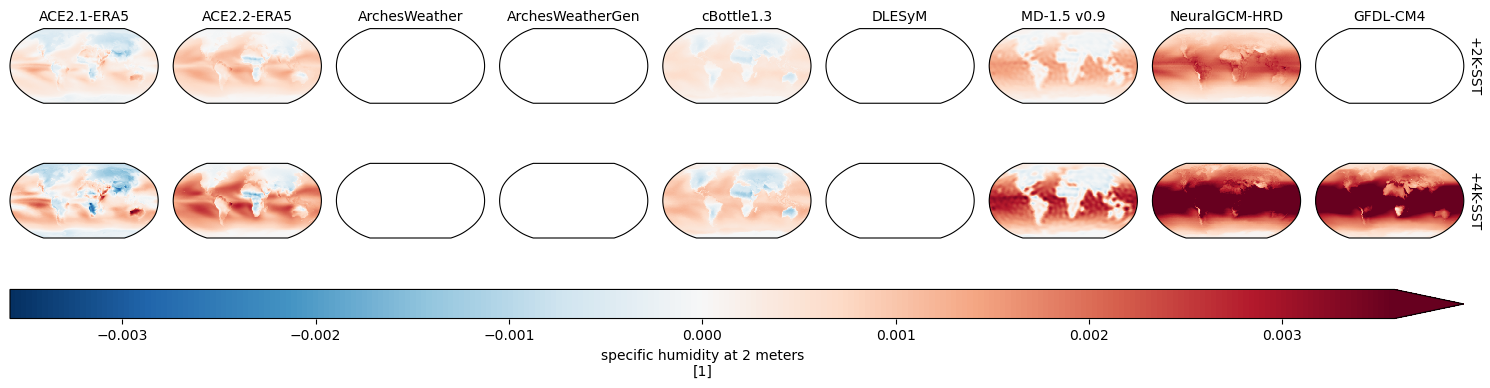

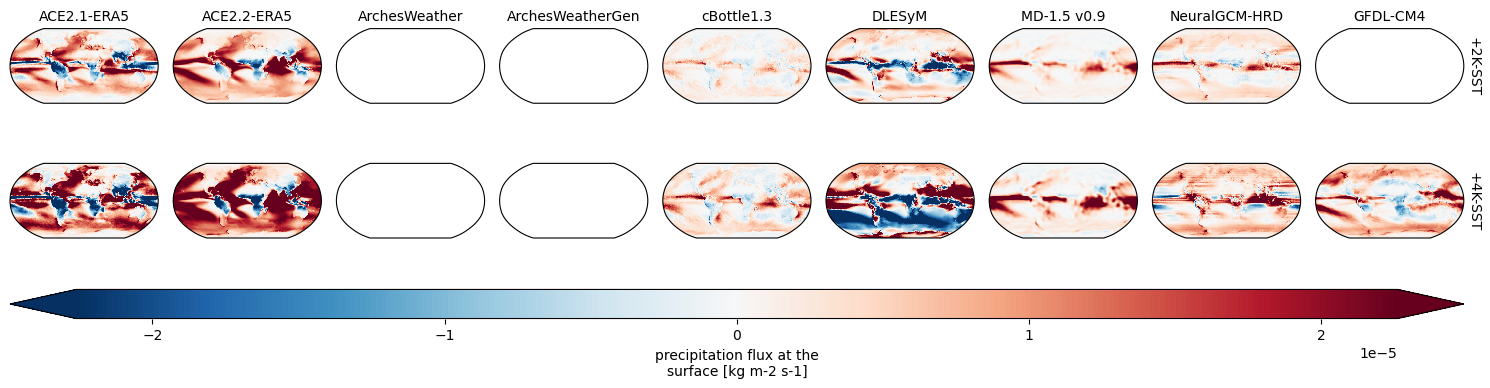

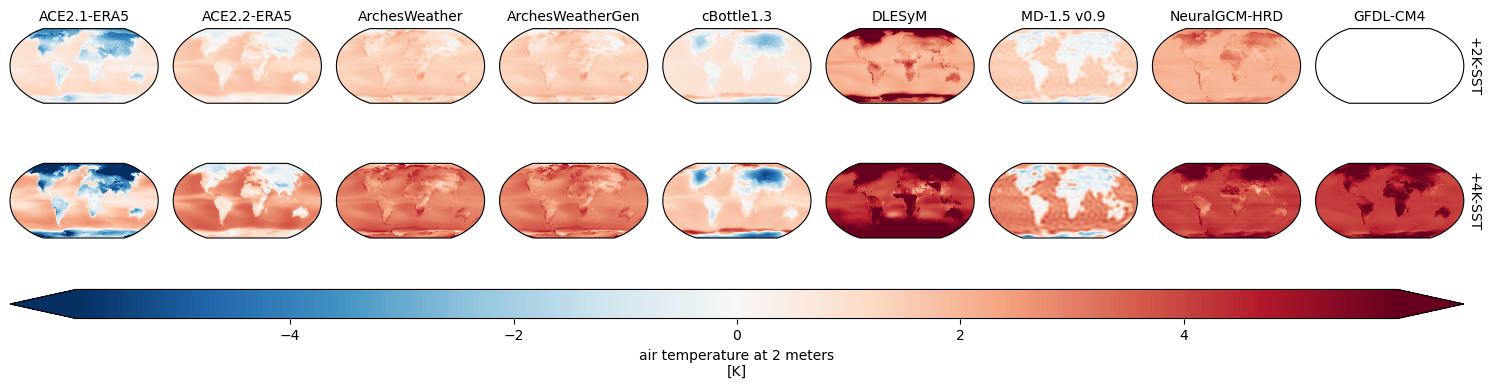

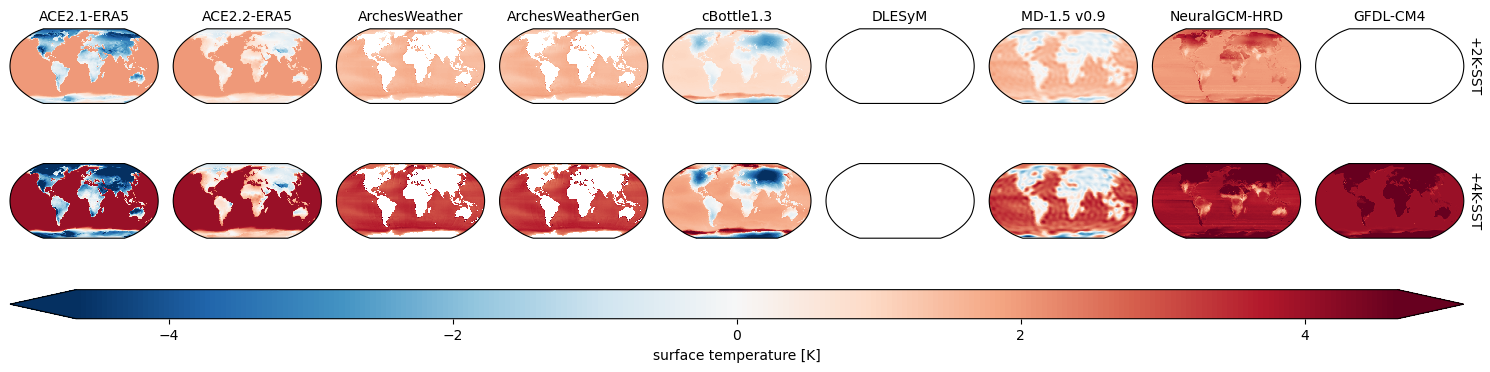

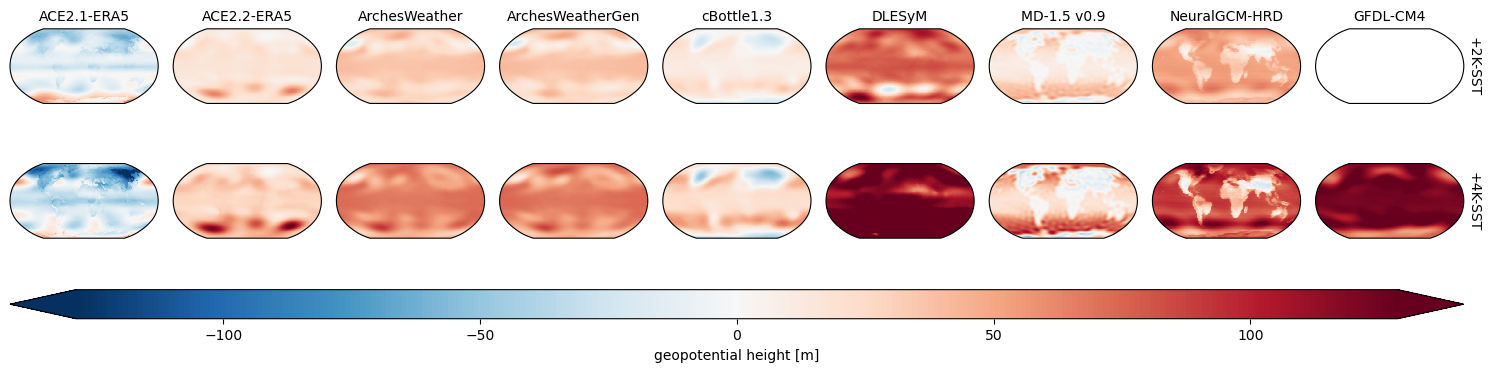

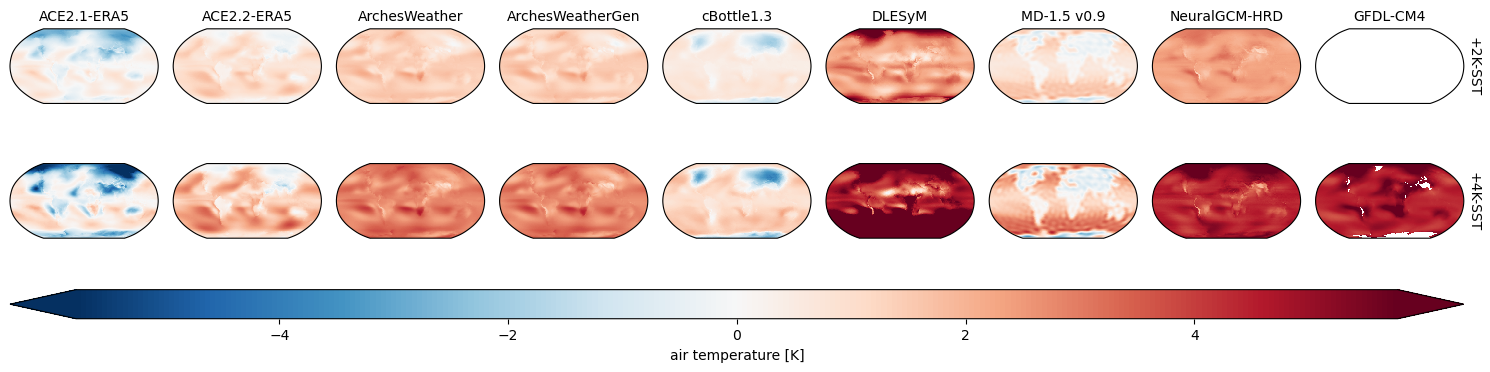

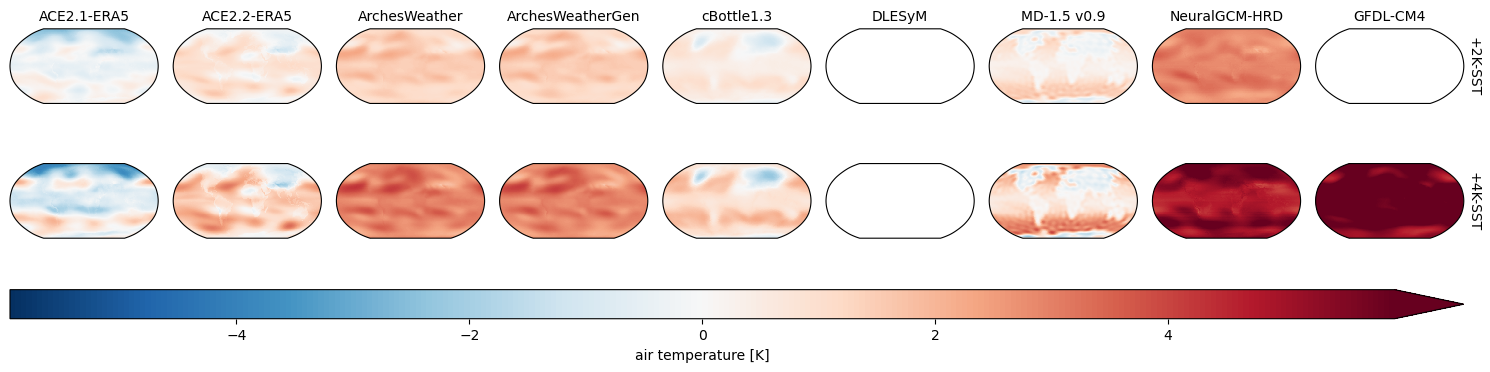

In [25]:
for var in combined_1deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_1deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.95)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_1deg_map_{var}.png'), bbox_inches='tight')

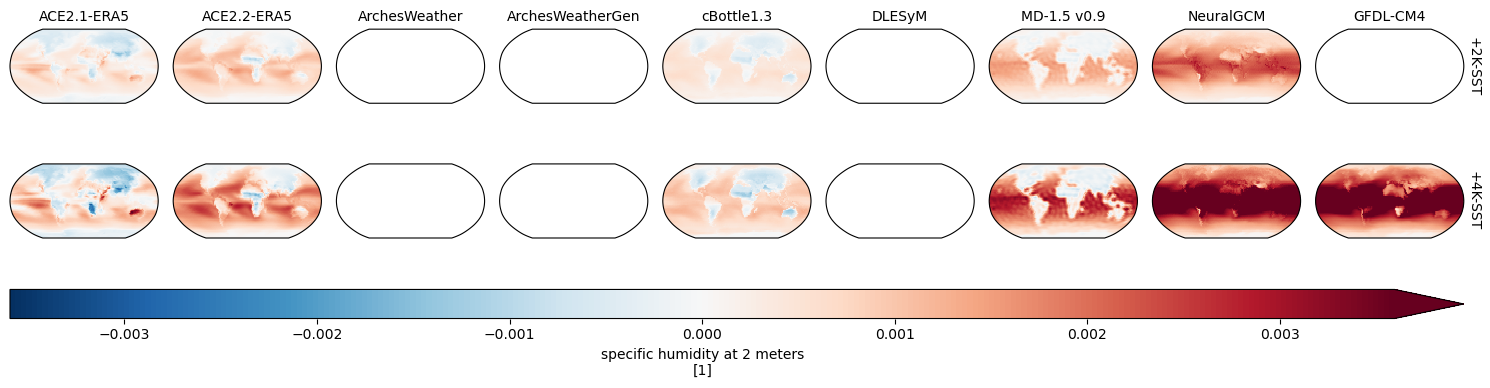

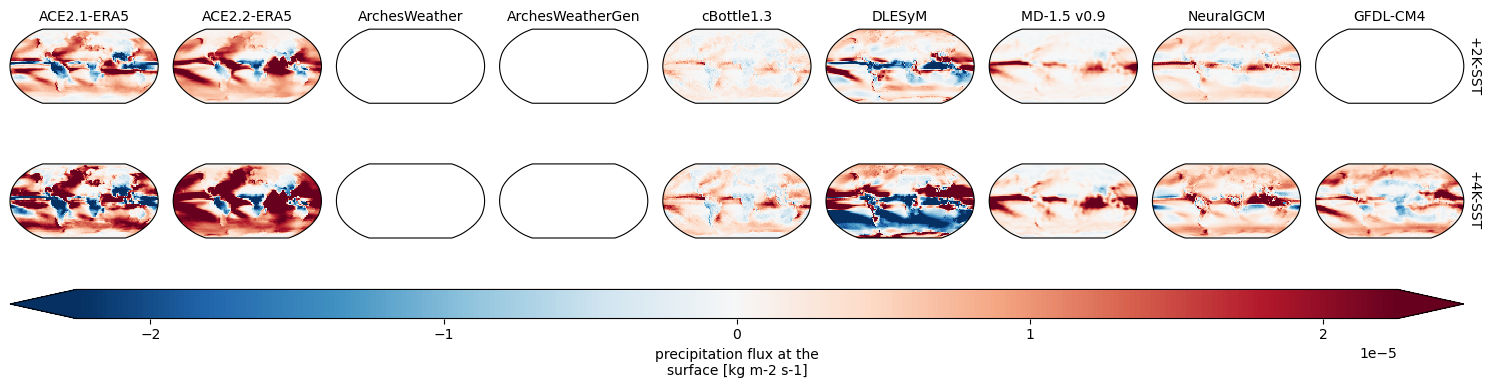

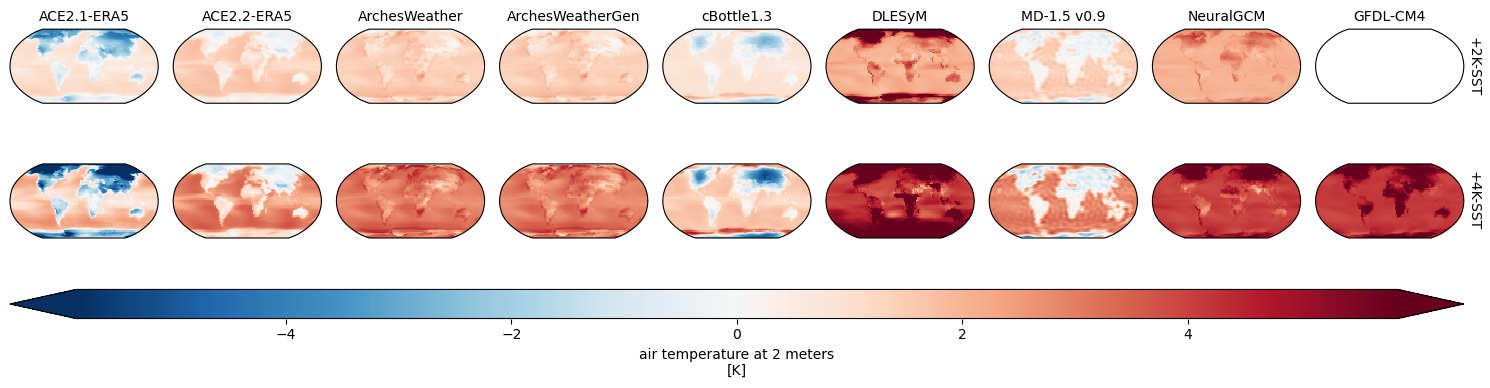

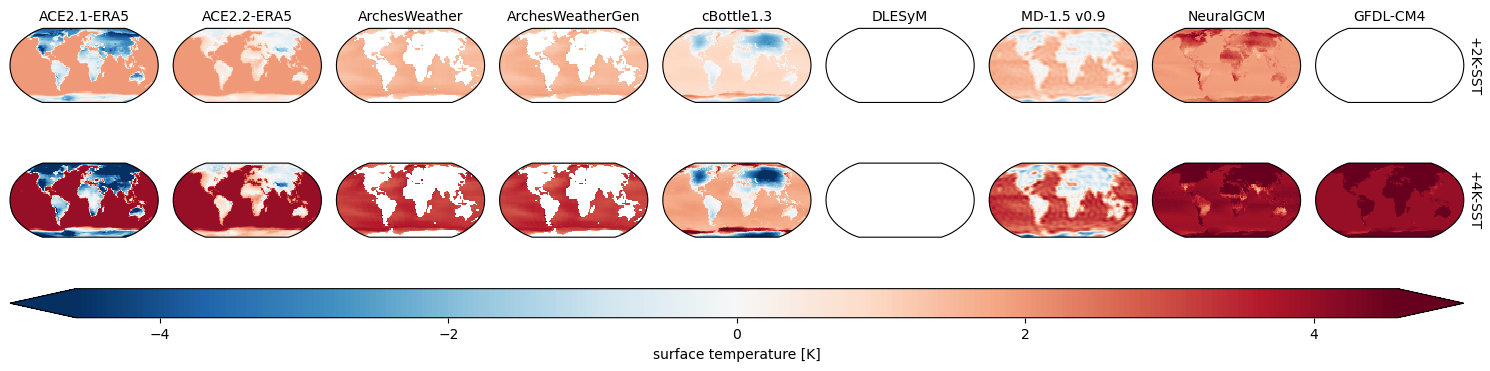

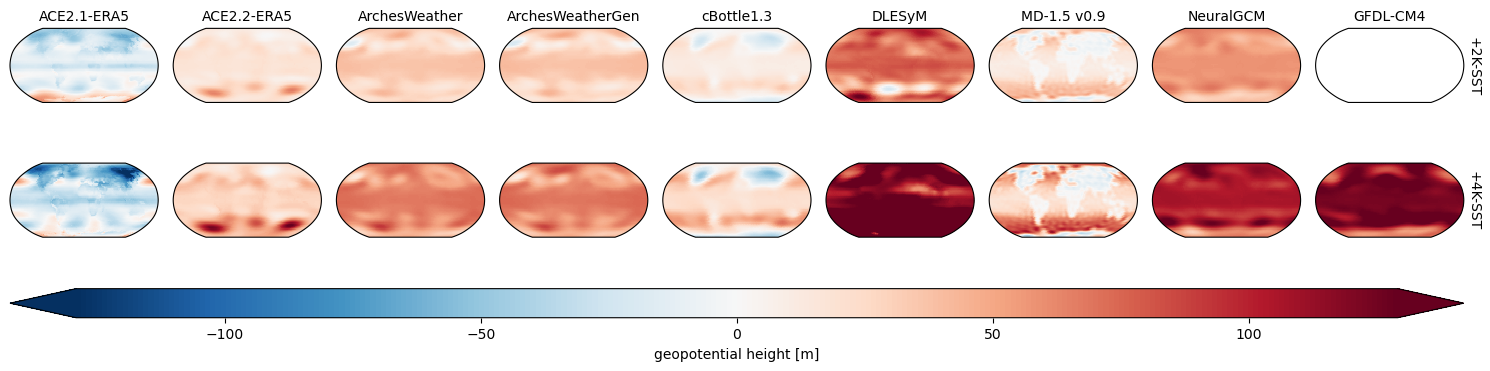

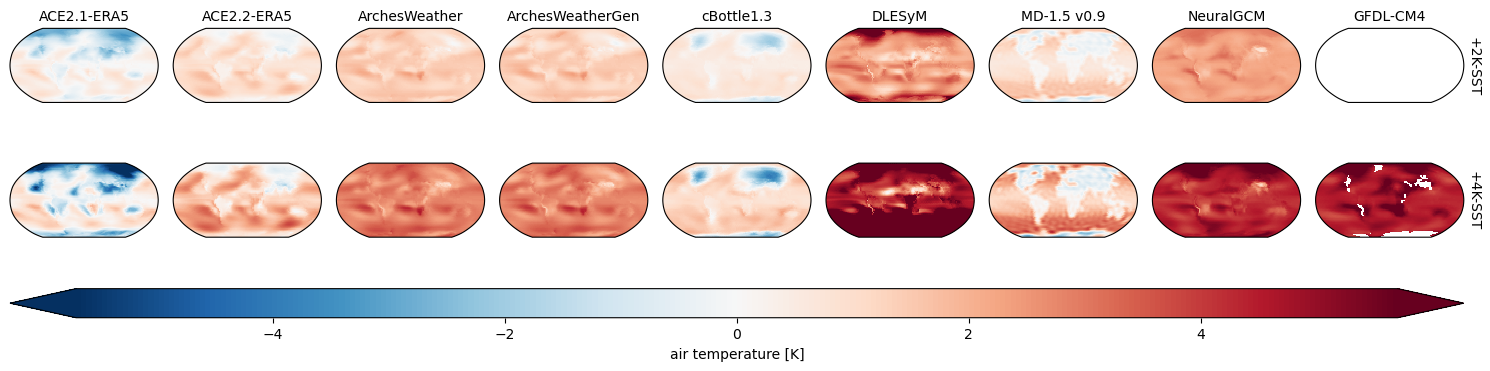

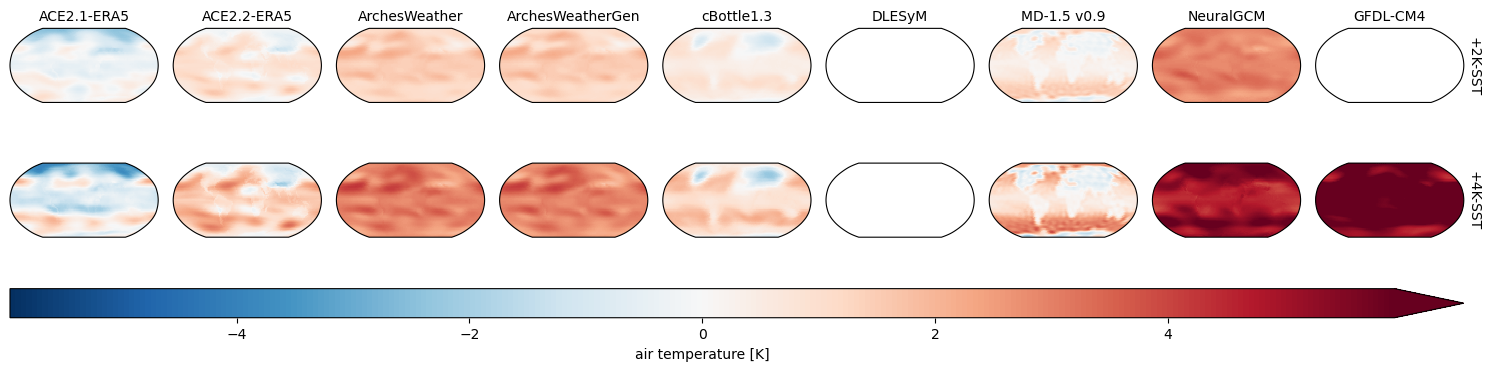

In [26]:
for var in combined_2p8deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_2p8deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.95)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_2p8deg_map_{var}.png'), bbox_inches='tight')

## Manuscript Figures

In [27]:
MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'eps'
GMD_SINGLE_COL_IN = 84 / 25.4
GMD_DOUBLE_COL_IN = 174 / 25.4
GMD_MAX_HEIGHT_IN = 170 / 25.4  # leave room for caption
LABEL_FS = 7

VAR_SCALE = {'pr': 86400.}
VAR_DISPLAY_UNITS = {'pr': 'mm day$^{-1}$'}

def ms_savefig(fig, name):
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, format=MANUSCRIPT_FORMAT)
    fig.savefig(os.path.join(MANUSCRIPT_DIR, f'{name}.png'), dpi=MANUSCRIPT_DPI, format='png')
    print(f'Saved {path}')

In [28]:
def _wrap_row_label(s, min_part=3, max_lines=2):
    """Split a model name into <=max_lines lines for a rotated row label.

    Prefer hyphen/space boundaries (keeps e.g. 'NeuralGCM'/'HRD' and
    'ACE2.2'/'ERA5' readable); fall back to CamelCase for single tokens such
    as 'ArchesWeatherGen'. Fold any excess parts at the join that minimises
    the longest resulting line, so the rotated label's vertical extent stays
    short enough to fit the (compressed, 9-row) row pitch without overprinting.
    """
    parts = [p for p in re.split(r'[-\s]+', s) if p]
    if len(parts) < 2:                       # no hyphen/space -> break CamelCase
        parts = re.split(r'(?<=[a-z])(?=[A-Z])', s)
    merged = [parts[0]]
    for p in parts[1:]:
        if len(merged[-1]) < min_part or len(p) < min_part:
            merged[-1] += p
        else:
            merged.append(p)
    while len(merged) > max_lines:
        best_i, best_longest = 0, float('inf')
        for i in range(len(merged) - 1):
            cand = merged[:i] + [merged[i] + merged[i + 1]] + merged[i + 2:]
            longest = max(len(x) for x in cand)
            if longest < best_longest:
                best_longest, best_i = longest, i
        merged = merged[:best_i] + [merged[best_i] + merged[best_i + 1]] + merged[best_i + 2:]
    return '\n'.join(merged)


def plot_perturbation_response_map(ds, vars_to_plot, save_name):
    perturbations = ['+2K-SST', '+4K-SST']
    pert_labels = {'+2K-SST': '+2K', '+4K-SST': '+4K'}
    exp_names = list(ds.experiment_submission.values)
    n_exp = len(exp_names)

    cols = [(var, pert) for var in vars_to_plot for pert in perturbations]
    n_cols, n_rows = len(cols), n_exp

    vlims = {
        var: float(
            abs(ds[var] * VAR_SCALE.get(var, 1.0)).quantile(0.95)
        )
        for var in vars_to_plot
    }

    map_h = (GMD_DOUBLE_COL_IN / n_cols) / 1.9
    fig_height = min(n_rows * map_h * 1.15 + 1.0, GMD_MAX_HEIGHT_IN)
    fig = plt.figure(figsize=(GMD_DOUBLE_COL_IN, fig_height))
    gs = fig.add_gridspec(nrows=n_rows, ncols=n_cols, hspace=0.08, wspace=0.05)
    fig.subplots_adjust(top=0.88, left=0.16)

    ims_by_var = {}
    axes_by_var = {var: [] for var in vars_to_plot}
    top_row_axes = {}
    col0_axes = {}

    panel_letter = ord('a')
    for row, exp in enumerate(exp_names):
        for col, (var, pert) in enumerate(cols):
            scale = VAR_SCALE.get(var, 1.0)
            ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
            axes_by_var[var].append(ax)
            if row == 0:
                top_row_axes[col] = ax
            if col == 0:
                col0_axes[row] = ax

            data_sel = ds[var].sel(experiment_submission=exp, perturbation=pert, drop=True) * scale

            if bool(np.isnan(data_sel.values).all()):
                ax.set_global()
            else:
                im = data_sel.plot(
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    cmap='RdBu_r',
                    vmin=-vlims[var], vmax=vlims[var],
                    add_colorbar=False,
                    add_labels=False, rasterized=True,
                )
                ims_by_var[var] = im
            ax.set_title('')
            ax.coastlines(color='gray', linewidth=0.5)

            if row == 0:
                letter = chr(panel_letter)
                panel_letter += 1
                ax.set_title(f'({letter}) {pert_labels[pert]}', fontsize=LABEL_FS, pad=3)

    # Colorbars
    for var in vars_to_plot:
        if var not in ims_by_var:
            continue
        units = VAR_DISPLAY_UNITS.get(var, ds[var].attrs.get('units', ''))
        long_name = ds[var].attrs.get('long_name', var).replace('_', ' ').lower()
        cbar = fig.colorbar(
            ims_by_var[var],
            ax=axes_by_var[var],
            orientation='horizontal',
            fraction=0.015, pad=0.06, aspect=25,
            extend='both',
        )
        cbar.set_label(f'{long_name} [{units}]', size=LABEL_FS)
        cbar.ax.tick_params(labelsize=LABEL_FS - 1)
        cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

    fig.canvas.draw()

    # Row labels: CamelCase line-breaking capped at 2 lines
    for row, exp in enumerate(exp_names):
        col0_axes[row].text(
            -0.12, 0.5, _wrap_row_label(exp),
            transform=col0_axes[row].transAxes,
            rotation=90, va='center', ha='center',
            fontsize=LABEL_FS, clip_on=False, multialignment='center',
        )

    # Variable group headers — offset raised to clear the panel titles
    for vi, var in enumerate(vars_to_plot):
        pos_l = top_row_axes[vi * 2].get_position()
        pos_r = top_row_axes[vi * 2 + 1].get_position()
        x_center = (pos_l.x0 + pos_r.x1) / 2
        long_name = ds[var].attrs.get('long_name', var).replace('_', ' ').lower()
        fig.text(x_center, pos_l.y1 + 0.04, long_name,
                 ha='center', va='bottom', fontsize=LABEL_FS)

    fig.patch.set_alpha(0.0)
    ms_savefig(fig, save_name)
    plt.show()

Saved ./figures/manuscript_figures/perturbation_response_map_tas_pr.eps


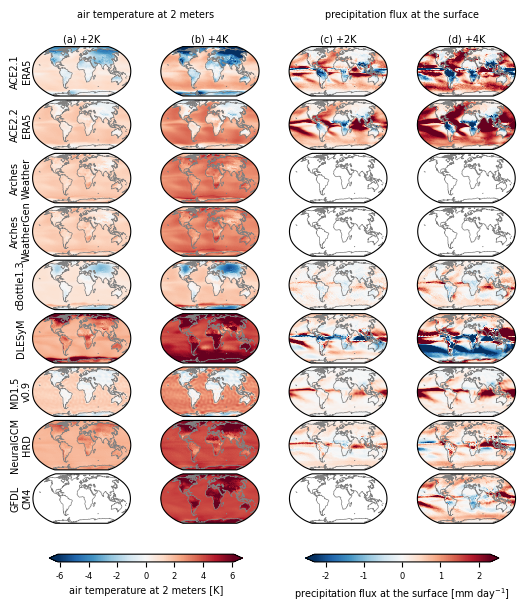

In [29]:
plot_perturbation_response_map(
    combined_1deg_perturbed_sst_response_time_means,
    vars_to_plot=['tas', 'pr'],
    save_name='perturbation_response_map_tas_pr',
)

## Appendix Figures

Saved ./figures/manuscript_figures/app_perturbation_response_map_2p8deg_tas_pr.eps


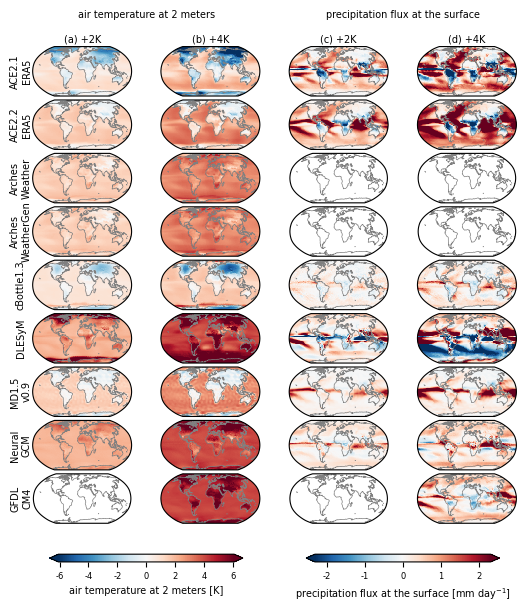

In [30]:
# Appendix Figure: perturbation response map at 2.8° resolution (NeuralGCM included)
plot_perturbation_response_map(
    combined_2p8deg_perturbed_sst_response_time_means,
    vars_to_plot=['tas', 'pr'],
    save_name='app_perturbation_response_map_2p8deg_tas_pr',
)